# Портфель инициатив: запрос текстом — отчёт с графиками

**Управленческий вопрос.** Когда портфель инициатив выходит в плюс и какие
инициативы тянут его назад?

Здесь не пишут SQL. Запрос формулируется словами, а ассистент сам ходит в базу,
строит графики и собирает короткий отчёт. Важно другое: каждый его вывод
опирается на выполненный запрос, а не на память модели — поэтому ответ можно
проверить.

**Паспорт инициативы** — четыре параметра, по которым инициатива превращается
в кривую NPV: месяц старта, расходы, число месяцев до выхода на прибыльность и
число месяцев до окупаемости. Одинаковая методика этих четырёх параметров делает
инициативы сравнимыми, а кривые — складываемыми в кривую портфеля.

In [1]:
import sys
sys.path.append("..")
from tools.report_agent import отчёт

## Запрос первый: когда портфель выходит в плюс

Обратите внимание на строки «шаг 1», «шаг 2» — это реальные обращения ассистента
к базе и построение графика. Ниже — его отчёт.

Запрос: Покажи кривую накопленного NPV портфеля по месяцам и скажи, в каком месяце портфель выходит в плюс



  шаг 1: run_sql(query=…)
     строк получено: 37


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


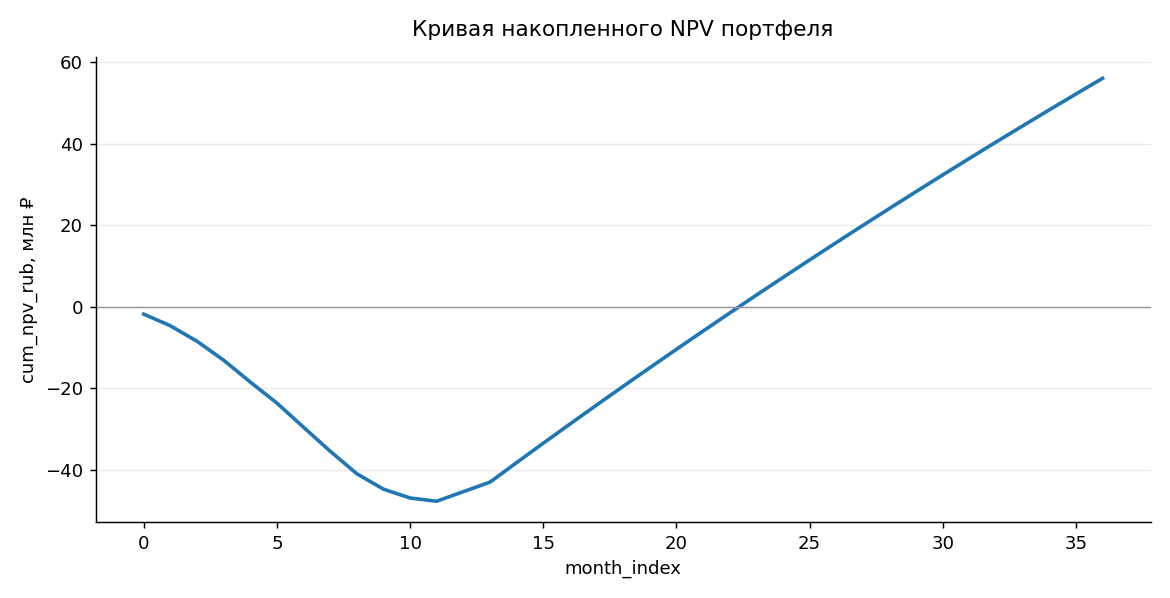

Портфель выходит в плюс на 23-м месяце после запуска инициатив. До этого момента наблюдается отрицательная динамика накопленного NPV, связанная с первоначальными инвестициями и затратами. С 23-го месяца начинается устойчивый рост показателя, свидетельствующий о положительном эффекте реализованных инициатив.

Рекомендация: продолжать мониторинг динамики NPV и оценивать влияние новых инициатив на общую эффективность портфеля.

In [2]:
отчёт("Покажи кривую накопленного NPV портфеля по месяцам и скажи, в каком месяце портфель выходит в плюс")

## Запрос второй: какие инициативы окупаются позже всех

Запрос: Сравни инициативы по месяцу окупаемости от начала портфеля (месяц старта плюс месяцев до окупаемости) и покажи столбчатой диаграммой три самые поздние



  шаг 1: run_sql(query=…)
     строк получено: 3


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


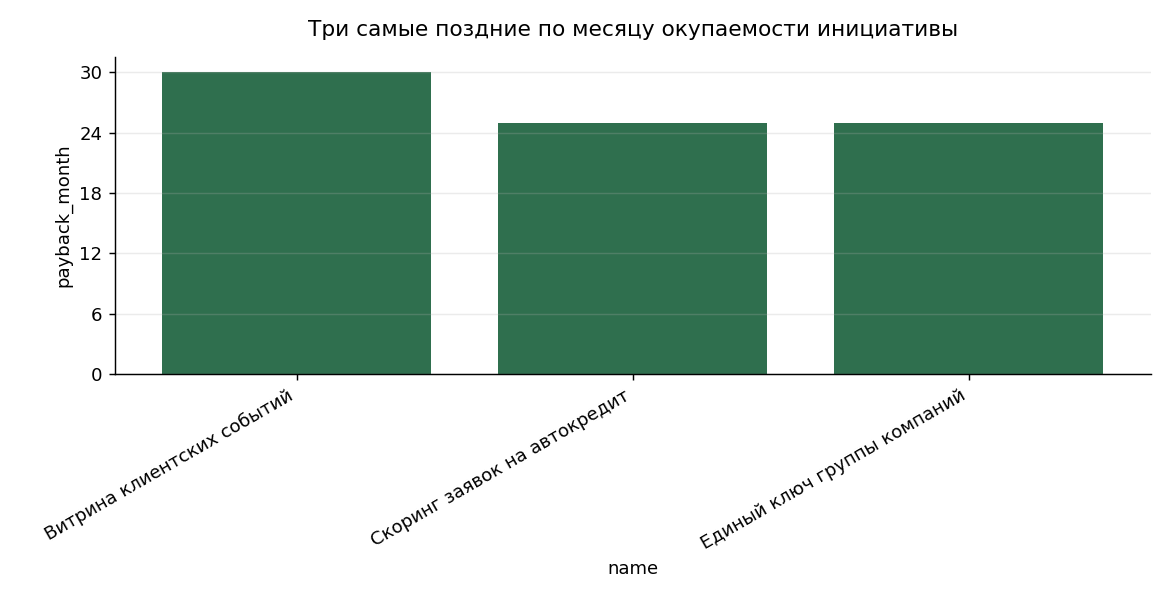

Самые поздние по сроку окупаемости инициативы:

- Витрина клиентских событий — 30-й месяц
- Скоринг заявок на автокредит — 25-й месяц
- Единый ключ группы компаний — 25-й месяц

График показывает распределение сроков окупаемости трёх самых поздних инициатив. Необходимо обратить внимание на инициативу "Витрина клиентских событий", так как она имеет самый длительный срок окупаемости среди представленных. Возможно, стоит пересмотреть её эффективность или рассмотреть возможность ускорения процесса возврата инвестиций.

In [3]:
отчёт("Сравни инициативы по месяцу окупаемости от начала портфеля (месяц старта плюс месяцев до окупаемости) и покажи столбчатой диаграммой три самые поздние")

## Запрос третий: куда уходят деньги

Запрос: Посчитай суммарные расходы по направлениям и покажи столбчатой диаграммой, где вложения самые большие



  шаг 1: run_sql(query=…)
     строк получено: 5


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


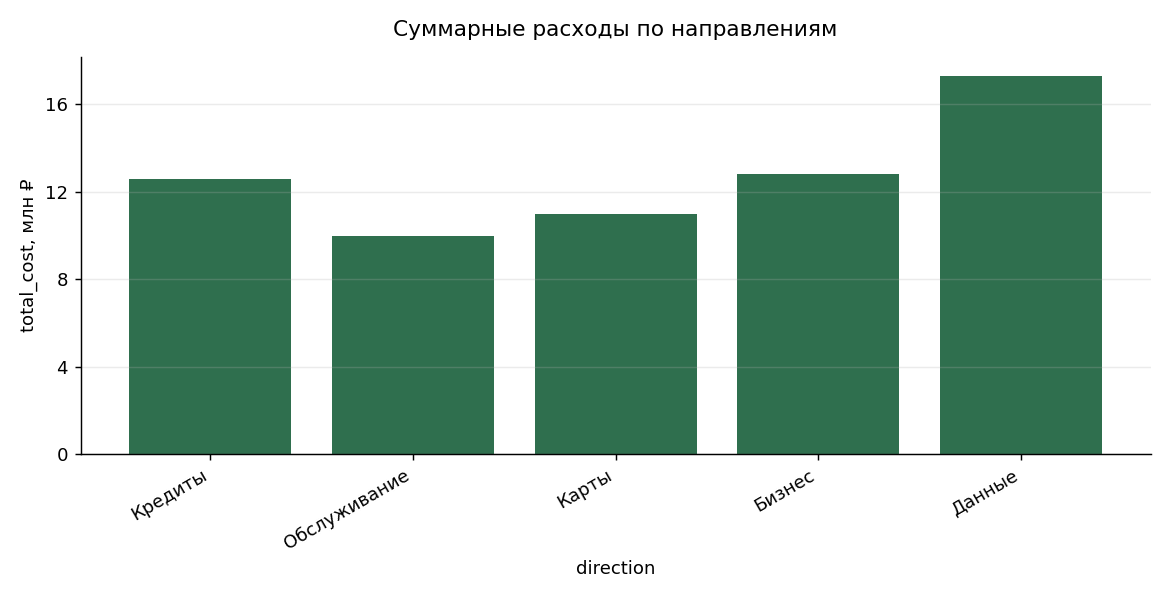

Самые крупные вложения у нас в направлении "Данные" — почти 17 млн рублей. На втором месте направление "Бизнес", там вложено около 12,8 млн рублей. Вложения в остальные направления примерно равны между собой и составляют порядка 10–12 млн рублей.

Рекомендую обратить внимание на эффективность вложений в направление "Данные". Возможно, стоит провести дополнительный анализ, чтобы убедиться, что эти инвестиции приносят ожидаемый эффект.

In [4]:
отчёт("Посчитай суммарные расходы по направлениям и покажи столбчатой диаграммой, где вложения самые большие")

## Как принимать такой отчёт

Ассистент отвечает уверенно всегда — и когда прав, и когда ошибся. Три проверки
занимают минуту и снимают большую часть риска:

1. **Сходится ли число с запросом.** Каждый шаг агента — это SQL, который можно
   выполнить самому. Если цифра в тексте не выводится из запроса, ей верить нельзя.
2. **Тот ли период и тот ли срез.** Частая ошибка — ответ посчитан по всем месяцам,
   когда спрашивали про горизонт наблюдения, или по всем инициативам, когда речь
   шла об одном направлении.
3. **Отличает ли агент план от факта.** В базе есть и плановая кривая из паспорта,
   и фактические расходы по месяцам. Вопрос «сколько потратили» и вопрос «сколько
   собирались потратить» дают разные числа.

Проверить любой шаг можно тем же запросом в тетради конвейера или прямо в базе.

## Задание

Сформулируйте свой вопрос к портфелю — так, как задали бы его аналитику словами,
без SQL. Например: «какие инициативы к концу горизонта не выходят в плюс» или
«как изменится кривая портфеля, если самая дорогая инициатива стартует на три
месяца позже». Прогоните его через `отчёт(...)` и проверьте ответ по трём пунктам
выше.